In [1]:

import torch
import matplotlib.pyplot as plt
import os
import numpy as np

os.chdir("..")
from utils import *
from core.SimulationEnvironment import *
from core.models import *
from config.constants import *
from config.two_bond_parameters import *
from training.pretraining_actor import *
from training.pretraining_critic import *
from training.train import *
torch.manual_seed(42)     
np.random.seed(42)
        
device_used = "cpu" #torch.device("cuda" if torch.cuda.is_available() else "cpu")


# 1. Constants and initialization

In [2]:
SELECTED_BONDS = [0, 5]

SIGMA = np.array(COV[np.ix_(SELECTED_BONDS, SELECTED_BONDS)])   

INTENSITIES = ARRIVAL_RATES[SELECTED_BONDS]            
SIZES = AVG_SIZES[SELECTED_BONDS]                   
NB_BONDS = len(SELECTED_BONDS)

LB_RISK = -3 * SIZES
UB_RISK =  3 * SIZES



In [3]:
# Initialize market
market_simulator = Market(
    lambdas_RFQ=INTENSITIES,
    Sigma=SIGMA,
    rf=RF,
    sizes=SIZES,
    f_parameters=(ALPHA, BETA, MU, SCALE),
)



In [4]:
# Initialize models
actors = [Actor(NB_BONDS, HIDDEN_DIM) for _ in range(NB_BONDS)]
critic = Critic(state_dim = NB_BONDS, hidden= HIDDEN_DIM)

# 2. Pretraining 

In [5]:

# Pretrain actors if not found
for j in SELECTED_BONDS:
    path = f"pretrained_actors/actor_{j}_{len(SELECTED_BONDS)}_scenario.pt"

    if not os.path.exists(path):
        myopic_p, myopic_delta = myopic_probs(
            SELECTED_BONDS,
            market_env=market_simulator
        )

        for i in range(NB_BONDS):
            pretrain_actor(
                actors[i],
                myopic_p[i],
                LB_RISK,
                UB_RISK,
                avg_sizes=SIZES,
                device=device_used
            )
        save_pretrained_actors(actors, SELECTED_BONDS)

In [6]:
# Pretrain Critic if not found
path = f"pretrained_critic/critic_bonds_{SELECTED_BONDS}_{len(SELECTED_BONDS)}_bond_scenario.pt"
if not os.path.exists(path):
    myopic_p, myopic_delta = myopic_probs(
            SELECTED_BONDS,
            market_env=market_simulator
        )

    critic_target, critic_input = produce_initial_value_grid(market_simulator, 
                                                            init_strategy= myopic_p,
                                                            lb_risk=LB_RISK, ub_risk=UB_RISK, nb_bonds=NB_BONDS, sizes=SIZES)

    critic = pretrain_critic(
        critic=critic,
        input= critic_input/SIZES.reshape(1, -1),
        target= critic_target
    )
    save_pretrained_critic(critic, list(SELECTED_BONDS))



# 3. Load and Train the model

In [20]:
# load the critic
critic = Critic(state_dim= NB_BONDS, hidden= HIDDEN_DIM)
save_path = os.path.join(f"pretrained_critic/critic_bonds_{SELECTED_BONDS}_{len(SELECTED_BONDS)}_bond_scenario.pt")
state_dict = torch.load(save_path, map_location="cpu") 
critic.load_state_dict(state_dict)
critic.to(device_used)

# and the actors 
actors = [Actor(state_dim=NB_BONDS, hidden=HIDDEN_DIM) for i in range(NB_BONDS)]
for i, b in enumerate(SELECTED_BONDS):
    path = f"pretrained_actors/actor_{b}_{len(SELECTED_BONDS)}_scenario.pt"
    state_dict = torch.load(path, map_location="cpu") 
    actors[i].load_state_dict(state_dict)
    actors[i].to(device_used)


C:\Users\tsito\AppData\Local\Temp\ipykernel_26776\3872622013.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(save_path, map_location="cpu")
C:\Us

In [ ]:
results = train_final(
    actors = actors,
    critic= critic,
    market=market_simulator,
    r= RF,
    Sigma= SIGMA,
    nb_steps=NB_STEPS,
    avg_sizes= SIZES,
    critic_batch_size=CRITIC_BATCH_SIZE, 
    actor_batch_size=ACTOR_BATCH_SIZE,
    critic_lr= 1e-2, 
    actor_lr= 3e-5,
    LB_init=LB_INIT[SELECTED_BONDS],
    UB_init=UB_INIT[SELECTED_BONDS], 
    LB_max=LB_FINAL[SELECTED_BONDS],
    UB_max=UB_FINAL[SELECTED_BONDS],
    nb_short_rollouts= 100, 
    short_horizon= 100, 
    long_horizon= LONG_HORIZON,
    update_risk_after= 50
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


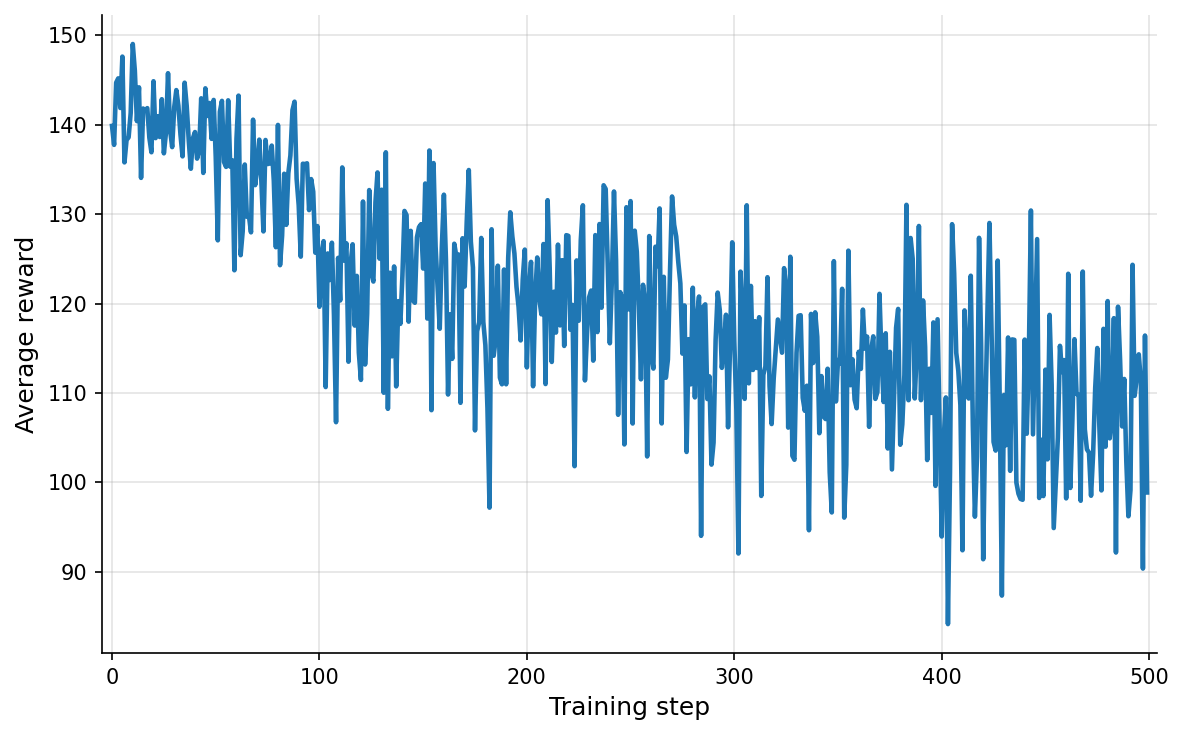

WindowsPath('figures/avg_reward_[0, 5].eps')

In [22]:
plot_avg_reward(results['avg_reward_long'], save_dir="figures", filename=f"avg_reward_{SELECTED_BONDS}.eps")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


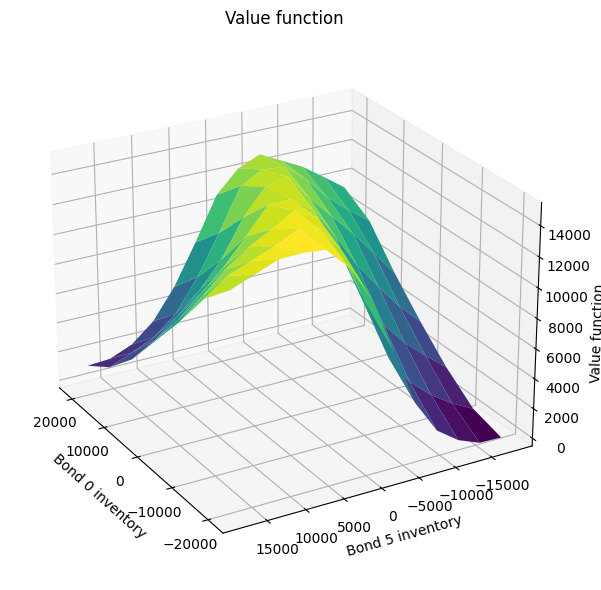

In [10]:
critic.eval()

device = next(critic.parameters()).device

grid_0 = np.arange(
    LB_RISK[0],
    UB_RISK[0] + AVG_SIZES[0],
    AVG_SIZES[0],
    dtype=np.float32
)

grid_1 = np.arange(
    LB_RISK[1],
    UB_RISK[1] + AVG_SIZES[1],
    AVG_SIZES[1],
    dtype=np.float32
)

Q0, Q1 = np.meshgrid(grid_0, grid_1, indexing="ij")

X = np.column_stack([
    Q0.ravel() / AVG_SIZES[0],
    Q1.ravel() / AVG_SIZES[1],
]).astype(np.float32)

with torch.no_grad():
    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    V = critic(X_t)
    if V.dim() == 2 and V.shape[1] == 1:
        V = V[:, 0]
    V = V.detach().cpu().numpy()

V_grid = V.reshape(Q0.shape)

out_path = Path(f"figures/learned_value_function_{SELECTED_BONDS}.eps")
out_path.parent.mkdir(parents=True, exist_ok=True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    Q0,
    Q1,
    V_grid,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
    shade=True
)

ax.set_xlabel(f"Bond {SELECTED_BONDS[0]} inventory")
ax.set_ylabel(f"Bond {SELECTED_BONDS[1]} inventory")
ax.set_zlabel("Value function")
ax.set_title("Value function")

ax.view_init(elev=25, azim=150)

plt.tight_layout()
fig.savefig(out_path, format="eps", bbox_inches="tight")
plt.show()

In [11]:
S_long, A_base_long, A_noisy_long, D_long, R_long, S_trade_long = rollout(
    policy=actors,
    starting_inventory=np.zeros(NB_BONDS),
    horizon=1000,
    market=market_simulator,
    r=RF,
    Sigma=SIGMA,
    lb= LB_INIT[SELECTED_BONDS], 
    ub= UB_INIT[SELECTED_BONDS],
    avg_sizes= SIZES
)


R_long = np.asarray(R_long, dtype=float).reshape(-1)
r_bar = float(R_long.mean()) if R_long.size > 0 else 0.0
print("Average reward per RFQ (Trained actor):", r_bar)

Average reward per RFQ (Trained actor): 135.0265657758713


# 5. Save the trained models


In [12]:
save_actors(actors, SELECTED_BONDS)
save_critic(critic, SELECTED_BONDS)
save_reward_to_csv(results['avg_reward_long'], f"bonds_{SELECTED_BONDS}", csv_path="data/reward_during_training.csv")



Actor saved to : 'trained_models/actor_0_2_scenario.pt'
Actor saved to : 'trained_models/actor_5_2_scenario.pt'
Critic saved to : 'trained_models/critic_bonds_[0, 5]_2_bond_scenario.pt'


WindowsPath('data/reward_during_training.csv')